# 19 — PWfE riaddestrato con la prosodia a finestre sovrapposte (C2)

**Domanda.** Inserendo nel modello completo la prosodia della configurazione C2 (finestre di 200 ms con passo di
150 ms, 16 canali), PWfE migliora? E soprattutto: batte il ramo Whisper da solo (Wf, 12,35% su DF 2021 eval)?

| Config. | Prosodia | Resto |
|---|---|---|
| **PWfE_200** (controllo) | 200/200 ms, 16 canali (come oggi) | identico |
| **PWfE_150** | 200/150 ms, 16 canali (C2) | identico |

**Protocollo: notebook 10, invariato.** Tre rami addestrati insieme da inizializzazione casuale; preprocessing
sul solo train (prosodia: clip 0,1–99,9 + min-max; Whisper ed ECAPA: standardizzazione per dimensione); Adam
lr 1e-3, batch 32, BCE con `pos_weight`, massimo 40 epoche; early stopping (pazienza 10), checkpoint e
`ReduceLROnPlateau` sull'EER ufficiale del dev (come nel codice del notebook 10). Unica differenza: **5 semi**
invece di 1. Controllo di riproduzione: PWfE_200 seme 0 deve ridare l'EER dev del notebook 10 (1,29%).

**Regole fissate prima dell'esecuzione.**
1. *Scelta sul dev*: la configurazione preferita è quella con EER dev medio sui 5 semi più basso.
2. *Successo su eval*: la configurazione preferita ha EER medio su DF 2021 eval **inferiore a Wf** (calcolato qui
   con `model_Wf_seed0.pt`, atteso 12,35%).

Su eval si riportano entrambe le configurazioni (EER, FPR/FNR alla soglia di EER, per sorgente e codec,
confronti appaiati per seme), più PWfE attuale e Wf come riferimenti. PWfE attuale deve ridare 16,09%: è il
controllo del caricamento delle feature eval.

**Fasi** (`FASE`): `addestramento` (circa 40 min su GPU), `inferenza` (le feature eval con passo 150 ms vengono
dal notebook 18; se mancano si valuta solo il controllo).

In [1]:
import os, re, json, time, copy, shutil, hashlib, importlib.util, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, PackedSequence

FASE = os.environ.get("FASE", "addestramento+inferenza")
INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
BASE = INPUT_ROOT / "datasets/angelopaldino"
# --- addestramento (notebook 10) ---
TRAIN_DIR = BASE / "outputtrain-feature-noft/ptm_features_train"
DEV_DIR = BASE / "devroot/root"
PROS200_TRDEV = BASE / "prosody-features/prosody_features"                       # standard_{train,dev}.npz
P17_DIR = Path(os.environ.get("P17_DIR", str(INPUT_ROOT / "datasets/angelo01paldino/riaddestramentop/p_riaddestramento")))
PROS150_TRDEV = P17_DIR / "prosodia_h150"                                         # standard_{train,dev}.npz
# --- eval (notebook 11 e 18) ---
DF_KEYS = BASE / "df-keys/CM/trial_metadata.txt"
PTM_EVAL = BASE / "features/resultsPTM/df2021/ptm"
PROS200_EVAL = BASE / "features/results_Prosodia/df2021/prosodia"
PROS150_EVAL = os.environ.get("PROS150_EVAL", "/kaggle/input/datasets/angelo01paldino/prosodiah150/eval_p/prosodia_h150")   # cartella 'prosodia_h150' del notebook 18; vuoto = ricerca automatica
MODELLI = BASE / "models/Modelli"                    # PWfE e Wf attuali, per riferimento
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/pwfe_riaddestrato"))
RIPRESA = os.environ.get("RIPRESA", "/kaggle/input/datasets/angelo01paldino/pwfenew/pwfe_riaddestrato")
MOD_DIR, SCO_DEV, SCO_EVAL = OUT_DIR / "modelli", OUT_DIR / "punteggi_dev", OUT_DIR / "punteggi_eval"
for d in (OUT_DIR, MOD_DIR, SCO_DEV, SCO_EVAL):
    d.mkdir(parents=True, exist_ok=True)

CONFIGURAZIONI = {"PWfE_200": PROS200_TRDEV, "PWfE_150": PROS150_TRDEV}
RIFERIMENTO = "PWfE_200"
SEMI = [int(s) for s in os.environ.get("SEMI", "0,1,2,3,4").split(",")]
MAX_EPOCHS = int(os.environ.get("MAX_EPOCHS", 40))
PATIENCE = int(os.environ.get("PATIENCE", 10))
LR_FACTOR, LR_PATIENCE = 0.5, 3
BATCH_SIZE, LR, DROPOUT = 32, 1e-3, 0.2
EVAL_BATCH = 64            # notebook 10 (dev)
EVAL_BATCH_DF = 256        # notebook 11 (eval)
D_WHISPER, D_ECAPA, EMB_DIM = 512, 192, 50
CLIP_PCT = (0.1, 99.9)
N_BOOT = int(os.environ.get("N_BOOT", 1000))
MIN_PER_CLASSE = 10
FEATURES = ["f0_mean", "f0_std", "jitter_local", "shimmer_local",
            "hnr_mean", "hnr_std", "intensity_mean", "intensity_std"]
RIF_DEV_N10 = float(os.environ.get("RIF_DEV_N10", 1.29))          # notebook 10, PWfE seme 0, EER dev (%)
TOLL_DEV = 0.05                                                     # controllo NON bloccante
RIF_EVAL = {"PWfE_attuale": float(os.environ.get("RIF_PWFE_EVAL", 16.0872)),   # notebook 11
            "Wf_attuale": float(os.environ.get("RIF_WF_EVAL", 12.3479))}
TOLL_EVAL = 0.01                                                    # controllo bloccante

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
if RIPRESA:
    assert Path(RIPRESA).exists(), RIPRESA
    shutil.copytree(RIPRESA, OUT_DIR, dirs_exist_ok=True)
    print("ripresa da", RIPRESA)
print(f"FASE = {FASE} | device {DEVICE} | torch {torch.__version__} | semi {SEMI}")

ripresa da /kaggle/input/datasets/angelo01paldino/pwfenew/pwfe_riaddestrato
FASE = addestramento+inferenza | device cuda | torch 2.10.0+cu128 | semi [0, 1, 2, 3, 4]


In [2]:
EVAL_METRICS_URL = "https://raw.githubusercontent.com/asvspoof-challenge/2021/main/eval-package/eval_metrics.py"
EVAL_METRICS_PATH = OUT_DIR / "eval_metrics.py"
if not EVAL_METRICS_PATH.exists():
    urllib.request.urlretrieve(EVAL_METRICS_URL, EVAL_METRICS_PATH)
spec = importlib.util.spec_from_file_location("asvspoof_eval_metrics", EVAL_METRICS_PATH)
asv_metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(asv_metrics)
EVAL_METRICS_SHA256 = hashlib.sha256(EVAL_METRICS_PATH.read_bytes()).hexdigest()
assert EVAL_METRICS_SHA256.startswith("70c5d2fe8fab6654"), EVAL_METRICS_SHA256[:16]

def eer_soglia(y, s):
    y, s = np.asarray(y), np.asarray(s, dtype=np.float64)
    eer, thr = asv_metrics.compute_eer(s[y == 1], s[y == 0])
    return float(eer), float(thr)

def compute_eer(y, s):
    return eer_soglia(y, s)[0]

def tassi(y, s, soglia):
    """Bona fide se punteggio > soglia (convenzione di compute_det_curve)."""
    tn, fp, fn, tp = confusion_matrix(np.asarray(y, int), (np.asarray(s) > soglia).astype(int), labels=[0, 1]).ravel()
    return {"FP": int(fp), "FN": int(fn), "FPR_%": 100 * fp / (fp + tn), "FNR_%": 100 * fn / (fn + tp)}

assert compute_eer([1, 1, 0, 0], [2.0, 3.0, 0.0, 1.0]) == 0.0
assert compute_eer([1, 1, 0, 0], [0.0, 1.0, 2.0, 3.0]) == 1.0
print("eval_metrics.py | sha256", EVAL_METRICS_SHA256[:16], "...")

eval_metrics.py | sha256 70c5d2fe8fab6654 ...


In [3]:
def masked_bn(x, mask, bn):
    y = torch.zeros_like(x)
    y[mask] = bn(x[mask])
    return y

def map_packed(p, fn):
    return PackedSequence(fn(p.data), p.batch_sizes, p.sorted_indices, p.unsorted_indices)

class SeqBranch(nn.Module):
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.conv1, self.bn_c1 = nn.Conv1d(n_in, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256)
        self.conv2, self.bn_c2 = nn.Conv1d(256, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p)
        self.lstm1, self.bn_l1 = nn.LSTM(128, 100, batch_first=True), nn.BatchNorm1d(100)
        self.lstm2, self.bn_l2 = nn.LSTM(100, 50, batch_first=True), nn.BatchNorm1d(50)
        self.att_w, self.att_v = nn.Linear(50, 50), nn.Linear(50, 1, bias=False)
        self.out_dim = EMB_DIM

    def conv_block(self, h, conv, bn, mask):
        h = conv(h.transpose(1, 2)).transpose(1, 2)
        h = F.relu(masked_bn(h, mask, bn))
        return self.drop(h) * mask.unsqueeze(-1)

    def forward(self, x, lengths):
        T = x.shape[1]
        mask = torch.arange(T, device=x.device)[None, :] < lengths.to(x.device)[:, None]
        h = self.conv_block(x, self.conv1, self.bn_c1, mask)
        h = self.conv_block(h, self.conv2, self.bn_c2, mask)
        p = pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p, _ = self.lstm1(p)
        p = map_packed(map_packed(p, self.bn_l1), self.drop)
        p, _ = self.lstm2(p)
        p = map_packed(p, self.bn_l2)
        H, _ = pad_packed_sequence(p, batch_first=True, total_length=T)
        e = self.att_v(torch.tanh(self.att_w(H))).squeeze(-1)
        a = torch.softmax(e.masked_fill(~mask, float("-inf")), dim=1)
        return (a.unsqueeze(-1) * H).sum(1), a

class FileBranch(nn.Module):
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, 128), nn.BatchNorm1d(128), nn.ReLU(),
                                 nn.Dropout(p), nn.Linear(128, EMB_DIM))
    def forward(self, x):
        return self.net(x)

class PWfE(nn.Module):
    """Notebook 10, variante PWfE: chiavi pb.*, wfb.*, eb.*, bn_fuse.*, head.* (costruite nello stesso ordine)."""
    def __init__(self, n_in_p=16, p=DROPOUT):
        super().__init__()
        self.pb = SeqBranch(n_in_p, p)
        self.wfb = FileBranch(D_WHISPER, p)
        self.eb = FileBranch(D_ECAPA, p)
        self.bn_fuse = nn.ModuleList([nn.BatchNorm1d(EMB_DIM) for _ in range(3)])
        self.head = nn.Sequential(nn.Linear(3 * EMB_DIM, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))
    def forward(self, xp, lp, xm, xe):
        zp, _ = self.pb(xp, lp)
        parts = [bn(z) for bn, z in zip(self.bn_fuse, [zp, self.wfb(xm), self.eb(xe)])]
        return self.head(torch.cat(parts, dim=1)).squeeze(-1)

class SoloWf(nn.Module):
    """Notebook 09/11, ramo Wf: chiavi wfb.* e head.*"""
    def __init__(self, p=DROPOUT):
        super().__init__()
        self.wfb = FileBranch(D_WHISPER, p)
        self.head = nn.Sequential(nn.Linear(EMB_DIM, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))
    def forward(self, xp, lp, xm, xe):
        return self.head(self.wfb(xm)).squeeze(-1)

print("PWfE:", sum(p.numel() for p in PWfE().parameters()), "parametri (notebook 10: 348.725)")

# --- preprocessing (notebook 10) ---
def voiced_mask(x):
    return np.abs(x).sum(1) > 0

def dynamic_features(x):
    v = voiced_mask(x); n = len(x)
    d_ok = np.zeros(n, dtype=bool); d_ok[1:] = v[1:] & v[:-1]
    d = np.zeros_like(x); d[d_ok] = x[d_ok] - x[np.where(d_ok)[0] - 1]
    return d, d_ok

_x = np.array([[180.], [195.], [170.], [0.], [175.], [190.], [185.]], dtype=np.float32)
assert dynamic_features(_x)[0][:, 0].tolist() == [0, 15, -25, 0, 0, 15, -5]

def con_delta(seqs):
    seqs16, valid = [], []
    for x in seqs:
        d, d_ok = dynamic_features(x)
        seqs16.append(np.concatenate([x, d], axis=1))
        valid.append(np.concatenate([np.repeat(voiced_mask(x)[:, None], x.shape[1], 1),
                                     np.repeat(d_ok[:, None], x.shape[1], 1)], axis=1))
    return seqs16, valid

def fit_prosody_preproc(seqs16, valid):
    allw, val = np.concatenate(seqs16), np.concatenate(valid)
    clip_lo = np.array([np.percentile(allw[val[:, j], j], CLIP_PCT[0]) for j in range(allw.shape[1])])
    clip_hi = np.array([np.percentile(allw[val[:, j], j], CLIP_PCT[1]) for j in range(allw.shape[1])])
    clipped = np.where(val, np.clip(allw, clip_lo, clip_hi), allw)
    lo, hi = clipped.min(0), clipped.max(0)
    rng_ = np.where(hi - lo > 0, hi - lo, 1.0)
    return {k: v.astype(np.float32) for k, v in
            {"clip_lo": clip_lo, "clip_hi": clip_hi, "minmax_lo": lo, "minmax_range": rng_}.items()}

def pack_prosody(seqs16, valid, pp):
    out = [((np.where(m, np.clip(x, pp["clip_lo"], pp["clip_hi"]), x) - pp["minmax_lo"]) / pp["minmax_range"])
           .astype(np.float32) for x, m in zip(seqs16, valid)]
    lens = np.array([len(x) for x in out], dtype=np.int64)
    return np.concatenate(out), np.concatenate([[0], np.cumsum(lens)]).astype(np.int64), lens

def fit_standardizer(X, chunk=100_000):
    s = np.zeros(X.shape[1], dtype=np.float64); ss = np.zeros(X.shape[1], dtype=np.float64); n = 0
    for i in range(0, len(X), chunk):
        b = X[i:i + chunk].astype(np.float64)
        s += b.sum(0); ss += (b * b).sum(0); n += len(b)
    mean = s / n
    std = np.sqrt(np.maximum(ss / n - mean * mean, 0.0))
    std[std < 1e-6] = 1.0
    return mean.astype(np.float32), std.astype(np.float32)

def batch_inputs(sp, idx):
    L = sp["len_p"][idx]
    Bp = torch.zeros(len(idx), int(L.max()), sp["Xp"].shape[1])
    for k, i in enumerate(idx):
        n = int(sp["len_p"][i])
        Bp[k, :n] = torch.from_numpy(sp["Xp"][sp["off_p"][i]:sp["off_p"][i] + n])
    return Bp, torch.from_numpy(L), torch.from_numpy(sp["wmean"][idx]), torch.from_numpy(sp["ecapa"][idx])

PWfE: 348725 parametri (notebook 10: 348.725)


In [4]:
def carica_split(split, d):
    idx = pd.read_csv(d / f"index_{split}.csv")
    utt = idx["utt_id"].to_numpy()
    z = np.load(d / f"whisper_mean_{split}.npz", allow_pickle=True)
    assert (z["utt_id"] == utt).all(); wm = z["whisper_mean"].astype(np.float32)
    z = np.load(d / f"ecapa_{split}.npz", allow_pickle=True)
    assert (z["utt_id"] == utt).all(); ec = z["ecapa"].astype(np.float32)
    assert np.isfinite(wm).all() and np.isfinite(ec).all()
    return {"utt": utt, "y": idx["y_bonafide"].to_numpy().astype(np.float32),
            "attack": idx["attack"].to_numpy(), "wmean_raw": wm, "ecapa_raw": ec}

def carica_prosodia(cartella, split, utt_ref):
    z = np.load(Path(cartella) / f"standard_{split}.npz", allow_pickle=True)
    X, off, utt = z["X"].astype(np.float32), z["offsets"].astype(np.int64), z["utt_id"]
    assert (utt == utt_ref).all(), f"ordine degli utt_id della prosodia diverso da index_{split}.csv ({cartella})"
    assert np.isfinite(X).all() and X.shape[1] == len(FEATURES)
    return [X[off[i]:off[i + 1]] for i in range(len(utt))]

if "addestramento" in FASE:
    SPLIT = {"train": carica_split("train", TRAIN_DIR), "dev": carica_split("dev", DEV_DIR)}
    Y_TR, Y_DEV = SPLIT["train"]["y"], SPLIT["dev"]["y"]
    POS_W = float((Y_TR == 0).sum() / (Y_TR == 1).sum())
    WM_MEAN, WM_STD = fit_standardizer(SPLIT["train"]["wmean_raw"])
    E_MEAN, E_STD = fit_standardizer(SPLIT["train"]["ecapa_raw"])
    for s in SPLIT.values():
        s["wmean"] = (s["wmean_raw"] - WM_MEAN) / WM_STD
        s["ecapa"] = (s["ecapa_raw"] - E_MEAN) / E_STD
    STD_JSON = {"whisper_file_mean": WM_MEAN.tolist(), "whisper_file_std": WM_STD.tolist(),
                "ecapa_mean": E_MEAN.tolist(), "ecapa_std": E_STD.tolist(), "fit_on": "solo train"}
    (OUT_DIR / "standardizer.json").write_text(json.dumps(STD_JSON))
    if (MODELLI / "standardizer.json").exists():           # controllo informativo: stesse statistiche del notebook 10?
        ref = json.loads((MODELLI / "standardizer.json").read_text())
        print("standardizer identico a quello del notebook 10:",
              all(np.allclose(np.asarray(ref[k], np.float32), np.asarray(STD_JSON[k], np.float32), rtol=1e-5, atol=1e-6)
                  for k in ("whisper_file_mean", "whisper_file_std", "ecapa_mean", "ecapa_std")))
    print({k: f"{len(v['y'])} file, bona fide {int(v['y'].sum())}" for k, v in SPLIT.items()}, "| pos_weight", round(POS_W, 4))

standardizer identico a quello del notebook 10: True
{'train': '25380 file, bona fide 2580', 'dev': '24844 file, bona fide 2548'} | pos_weight 8.8372


In [5]:
def evaluate(model, sp, y, loss_fn, bs=EVAL_BATCH):
    model.eval(); scores, tot = [], 0.0
    with torch.no_grad():
        for k in range(0, len(y), bs):
            idx = np.arange(k, min(k + bs, len(y)))
            Bp, Lp, Bm, Be = batch_inputs(sp, idx)
            out = model(Bp.to(DEVICE), Lp, Bm.to(DEVICE), Be.to(DEVICE))
            tot += loss_fn(out, torch.from_numpy(y[idx]).to(DEVICE)).item() * len(idx)
            scores.append(out.cpu().numpy())
    return tot / len(y), np.concatenate(scores)

def train_run(data, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    model = PWfE(data["train"]["Xp"].shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_W, device=DEVICE))
    ytr_t = torch.from_numpy(Y_TR)
    g = np.random.default_rng(seed)
    best = {"eer": np.inf, "epoch": 0, "state": None}
    hist, bad = [], 0
    for ep in range(1, MAX_EPOCHS + 1):
        model.train(); tr_loss, n = 0.0, 0
        perm = g.permutation(len(Y_TR))
        for k in range(0, len(perm), BATCH_SIZE):
            b = perm[k:k + BATCH_SIZE]
            if len(b) < 2:
                continue
            Bp, Lp, Bm, Be = batch_inputs(data["train"], b)
            out = model(Bp.to(DEVICE), Lp, Bm.to(DEVICE), Be.to(DEVICE))
            loss = loss_fn(out, ytr_t[b].to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * len(b); n += len(b)
        dv_loss, dv_scores = evaluate(model, data["dev"], Y_DEV, loss_fn)
        dv_eer = compute_eer(Y_DEV, dv_scores)
        hist.append({"epoch": ep, "lr": opt.param_groups[0]["lr"], "train_loss": tr_loss / n,
                     "dev_loss": dv_loss, "dev_eer": dv_eer})
        sched.step(dv_eer)
        if dv_eer < best["eer"]:
            best = {"eer": dv_eer, "epoch": ep, "state": copy.deepcopy(model.state_dict())}; bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    model.load_state_dict(best["state"])
    _, scores = evaluate(model, data["dev"], Y_DEV, loss_fn)
    return model, scores, hist, best["epoch"], ep

F_RES, F_HIST = OUT_DIR / "risultati_dev.csv", OUT_DIR / "storia.csv"
def leggi_res():
    return pd.read_csv(F_RES).to_dict("records") if F_RES.exists() else []

if "addestramento" in FASE:
    t_all = time.perf_counter()
    for cfg, cartella in CONFIGURAZIONI.items():
        data = {}
        seq_tr = con_delta(carica_prosodia(cartella, "train", SPLIT["train"]["utt"]))
        PP = fit_prosody_preproc(*seq_tr)
        (OUT_DIR / f"preproc_prosody_{cfg}.json").write_text(json.dumps(
            {"config": cfg, "cartella": str(cartella), **{k: v.tolist() for k, v in PP.items()}}))
        for split, sq in (("train", seq_tr), ("dev", con_delta(carica_prosodia(cartella, "dev", SPLIT["dev"]["utt"])))):
            Xp, off, lens = pack_prosody(*sq, PP)
            data[split] = {"Xp": Xp, "off_p": off, "len_p": lens,
                           "wmean": SPLIT[split]["wmean"], "ecapa": SPLIT[split]["ecapa"]}
        if cfg == RIFERIMENTO and (MODELLI / "preproc_prosody.json").exists():
            ref = json.loads((MODELLI / "preproc_prosody.json").read_text())
            print("preprocessing prosodico di PWfE_200 identico al notebook 10:",
                  all(np.allclose(np.asarray(ref[k], np.float32), PP[k], rtol=1e-5, atol=1e-6)
                      for k in ("clip_lo", "clip_hi", "minmax_lo", "minmax_range")))
        print(f"=== {cfg}: train {data['train']['Xp'].shape} finestre | mediana per file {np.median(data['train']['len_p']):.0f}")
        for sd in SEMI:
            tag = f"{cfg}_s{sd}"
            f_sc, f_mod = SCO_DEV / f"{tag}.npy", MOD_DIR / f"model_{tag}.pt"
            if f_sc.exists() and f_mod.exists() and any(r["run"] == tag for r in leggi_res()):
                continue
            t0 = time.perf_counter()
            model, scores, hist, best_ep, last_ep = train_run(data, sd)
            torch.save(model.state_dict(), f_mod); np.save(f_sc, scores)
            pd.DataFrame([{**h, "run": tag} for h in hist]).to_csv(F_HIST, mode="a", index=False, header=not F_HIST.exists())
            rows = [r for r in leggi_res() if r["run"] != tag]
            rows.append({"run": tag, "config": cfg, "seed": sd, "eer_dev_%": 100 * compute_eer(Y_DEV, scores),
                         "auc_dev": roc_auc_score(Y_DEV, scores), "best_epoch": best_ep, "last_epoch": last_ep,
                         "minuti": (time.perf_counter() - t0) / 60})
            pd.DataFrame(rows).to_csv(F_RES, index=False)
            r = rows[-1]
            print(f"{tag}: EER dev {r['eer_dev_%']:.2f}% | epoca migliore {best_ep}, fermato a {last_ep} | {r['minuti']:.1f} min")
            if cfg == RIFERIMENTO and sd == 0:
                ok = abs(r["eer_dev_%"] - RIF_DEV_N10) <= TOLL_DEV
                print(f"  riproduzione notebook 10 (seme 0): {r['eer_dev_%']:.2f}% contro {RIF_DEV_N10}% -> "
                      + ("RIPRODOTTO" if ok else "NON riprodotto (non bloccante: i confronti restano interni a questo notebook)"))
        del data, seq_tr
    print(f"addestramento: {(time.perf_counter() - t_all) / 60:.1f} min")

PREFERITA, riep_dev = None, pd.DataFrame()
if F_RES.exists():
    RD = pd.DataFrame(leggi_res())
    per_seme_dev = RD.pivot(index="seed", columns="config", values="eer_dev_%")
    riep_dev = RD.groupby("config")["eer_dev_%"].agg(["mean", "std", "min", "max", "count"])
    print("=== EER dev (%) per seme ==="); display(per_seme_dev.round(2))
    print("=== EER dev (%) per configurazione ==="); display(riep_dev.round(3))
    completi = [c for c in CONFIGURAZIONI if c in riep_dev.index and riep_dev.loc[c, "count"] == len(SEMI)]
    PREFERITA = min(completi, key=lambda c: riep_dev.loc[c, "mean"]) if len(completi) == len(CONFIGURAZIONI) else None
    print("REGOLA 1 (dev) -> configurazione preferita:", PREFERITA if PREFERITA else "non decidibile (configurazioni incomplete)")
    riep_dev.to_csv(OUT_DIR / "riepilogo_dev.csv")

preprocessing prosodico di PWfE_200 identico al notebook 10: True
=== PWfE_200: train (434766, 16) finestre | mediana per file 16
=== PWfE_150: train (575427, 16) finestre | mediana per file 21
addestramento: 0.1 min
=== EER dev (%) per seme ===


config,PWfE_150,PWfE_200
seed,,
0,1.06,1.29
1,1.22,1.30
2,1.49,1.34
3,1.53,1.33
4,1.25,1.37


=== EER dev (%) per configurazione ===


,mean,std,min,max,count
config,,,,,
PWfE_150,1.309,0.196,1.059,1.530,5
PWfE_200,1.327,0.033,1.289,1.373,5


REGOLA 1 (dev) -> configurazione preferita: PWfE_150


In [6]:
def trova_pros150_eval():
    if PROS150_EVAL:
        return Path(PROS150_EVAL)
    hits = []
    for dirpath, dirnames, filenames in os.walk(INPUT_ROOT):
        dirnames[:] = [d for d in dirnames if d not in ("flac", "evalzenodo")]
        if Path(dirpath).name == "prosodia_h150" and "pros_0000.npz" in filenames:
            hits.append(Path(dirpath))
    return hits[0] if len(hits) == 1 else None

if "inferenza" in FASE:
    COLS = ["speaker", "utt_id", "codec", "source", "attack", "label", "trim", "subset", "vocoder",
            "c9", "c10", "c11", "c12"]
    meta = pd.read_csv(DF_KEYS, sep=r"\s+", header=None, names=COLS, dtype=str, engine="python")
    meta = meta[meta["subset"] == "eval"].reset_index(drop=True)
    UTT_E = meta["utt_id"].to_numpy(); POS_E = {u: i for i, u in enumerate(UTT_E)}
    Y_E = (meta["label"] == "bonafide").to_numpy().astype(np.int8)
    N = len(UTT_E)

    WM_E = np.full((N, D_WHISPER), np.nan, np.float32); EC_E = np.full((N, D_ECAPA), np.nan, np.float32)
    for p in sorted(PTM_EVAL.glob("ptm_*.npz")):
        z = np.load(p, allow_pickle=True)
        ii = np.array([POS_E[u] for u in z["utt_id"]])
        WM_E[ii] = z["whisper_mean"]; EC_E[ii] = z["ecapa"]
    assert np.isfinite(WM_E).all() and np.isfinite(EC_E).all(), "feature PTM eval incomplete"

    def carica_pros_eval(cartella):
        seqs = [None] * N
        for p in sorted(Path(cartella).glob("pros_*.npz")):
            z = np.load(p, allow_pickle=True)
            X, off, utt = z["X"], z["offsets"].astype(np.int64), z["utt_id"]
            for j, u in enumerate(utt):
                if u in POS_E:
                    seqs[POS_E[u]] = X[off[j]:off[j + 1]]
        manca = sum(s is None for s in seqs)
        assert manca == 0, f"{manca} prove senza prosodia in {cartella}"
        return con_delta(seqs)

    def dati_eval(seq16, pp, std):
        Xp, off, lens = pack_prosody(*seq16, {k: np.asarray(pp[k], np.float32) for k in
                                             ("clip_lo", "clip_hi", "minmax_lo", "minmax_range")})
        return {"Xp": Xp, "off_p": off, "len_p": lens,
                "wmean": (WM_E - np.asarray(std["whisper_file_mean"], np.float32)) / np.asarray(std["whisper_file_std"], np.float32),
                "ecapa": (EC_E - np.asarray(std["ecapa_mean"], np.float32)) / np.asarray(std["ecapa_std"], np.float32)}

    @torch.no_grad()
    def punteggi_eval(model, sp):
        model.eval(); out = []
        for k in range(0, N, EVAL_BATCH_DF):
            idx = np.arange(k, min(k + EVAL_BATCH_DF, N))
            Bp, Lp, Bm, Be = batch_inputs(sp, idx)
            out.append(model(Bp.to(DEVICE), Lp, Bm.to(DEVICE), Be.to(DEVICE)).cpu().numpy())
        return np.concatenate(out)

    def valuta(nome, costruttore, ckpt, sp):
        f = SCO_EVAL / f"{nome}.npy"
        if not f.exists():
            m = costruttore().to(DEVICE)
            m.load_state_dict(torch.load(ckpt, map_location=DEVICE), strict=True)
            np.save(f, punteggi_eval(m, sp))
        s = np.load(f)
        print(f"{nome}: EER eval {100 * compute_eer(Y_E, s):.2f}%")
        return s

    seq200 = carica_pros_eval(PROS200_EVAL)
    # riferimenti: modelli attuali con le loro statistiche (notebook 10/11)
    sp_ref = dati_eval(seq200, json.loads((MODELLI / "preproc_prosody.json").read_text()),
                       json.loads((MODELLI / "standardizer.json").read_text()))
    for nome, costr, ck in (("PWfE_attuale", PWfE, MODELLI / "model_PWfE_seed0.pt"),
                            ("Wf_attuale", SoloWf, MODELLI / "model_Wf_seed0.pt")):
        e = 100 * compute_eer(Y_E, valuta(nome, costr, ck, sp_ref))
        assert abs(e - RIF_EVAL[nome]) < TOLL_EVAL, f"{nome}: {e:.4f}% invece di {RIF_EVAL[nome]}%: caricamento eval non coerente"
    print("controllo superato: PWfE e Wf attuali riproducono il notebook 11")
    del sp_ref

    std_nuovo = json.loads((OUT_DIR / "standardizer.json").read_text())
    p150 = trova_pros150_eval()
    sorgenti = {"PWfE_200": seq200}
    if p150 is not None and len(list(p150.glob("pros_*.npz"))) >= int(np.ceil(N / 1000)):
        sorgenti["PWfE_150"] = None
    else:
        print("prosodia eval con passo 150 ms non disponibile o incompleta (notebook 18): PWfE_150 non valutato su eval")
    for cfg in sorgenti:
        seq = seq200 if cfg == "PWfE_200" else carica_pros_eval(p150)
        sp = dati_eval(seq, json.loads((OUT_DIR / f"preproc_prosody_{cfg}.json").read_text()), std_nuovo)
        for sd in SEMI:
            valuta(f"{cfg}_s{sd}", lambda c=cfg: PWfE(16), MOD_DIR / f"model_{cfg}_s{sd}.pt", sp)
        del sp, seq

PWfE_attuale: EER eval 16.09%
Wf_attuale: EER eval 12.35%
controllo superato: PWfE e Wf attuali riproducono il notebook 11
PWfE_200_s0: EER eval 16.09%
PWfE_200_s1: EER eval 17.72%
PWfE_200_s2: EER eval 17.49%
PWfE_200_s3: EER eval 13.98%
PWfE_200_s4: EER eval 16.54%
PWfE_150_s0: EER eval 17.20%
PWfE_150_s1: EER eval 14.24%
PWfE_150_s2: EER eval 14.55%
PWfE_150_s3: EER eval 17.45%
PWfE_150_s4: EER eval 17.51%


=== DF 2021 eval, per modello ===


,config,eer_%,auc,soglia_eer,FP,FN,FPR_%,FNR_%
modello,,,,,,,,
PWfE_150_s0,PWfE_150,17.203,0.902,-12.463,89286,2558,17.202,17.204
PWfE_150_s1,PWfE_150,14.244,0.939,-9.327,73937,2118,14.244,14.244
PWfE_150_s2,PWfE_150,14.547,0.923,-6.988,75508,2163,14.547,14.547
PWfE_150_s3,PWfE_150,17.452,0.909,-13.409,90588,2595,17.452,17.452
PWfE_150_s4,PWfE_150,17.513,0.915,-10.157,90903,2604,17.513,17.513
PWfE_200_s0,PWfE_200,16.087,0.914,-7.551,83502,2392,16.087,16.087
PWfE_200_s1,PWfE_200,17.722,0.904,-9.638,91994,2635,17.723,17.721
PWfE_200_s2,PWfE_200,17.488,0.906,-8.772,90780,2600,17.489,17.486
PWfE_200_s3,PWfE_200,13.982,0.933,-8.091,72575,2079,13.982,13.982


=== DF 2021 eval, per configurazione ===


,n,eer_media,eer_std,eer_min,eer_max,auc_media,FPR_media,FNR_media
config,,,,,,,,
Wf_attuale,1,12.348,NaN,12.348,12.348,0.952,12.348,12.348
PWfE_attuale,1,16.087,NaN,16.087,16.087,0.914,16.087,16.087
PWfE_200,5,16.365,1.491,13.982,17.722,0.913,16.365,16.364
PWfE_150,5,16.192,1.647,14.244,17.513,0.917,16.192,16.192



=== per source (media sui semi; FPR/FNR alla soglia di EER globale) ===


...


=== per codec (media sui semi; FPR/FNR alla soglia di EER globale) ===


eer_gruppo_%                                FPR_%_soglia_globale  \
config     Wf_attuale PWfE_attuale PWfE_200 PWfE_150           Wf_attuale   
gruppo                                                                      
high_m4a        14.09        19.91    20.25    19.16                14.18   
high_mp3        14.27        20.27    20.37    19.38                12.89   
high_ogg        10.29        12.39    12.81    13.06                15.52   
low_m4a         14.21        20.07    20.10    19.37                12.87   
low_mp3         14.74        21.49    21.35    20.51                10.43   
low_ogg         10.68        13.21    13.39    13.90                10.79   
mp3m4a          11.09        13.52    13.91    14.10                 9.80   
nocodec         13.84        19.46    19.68    18.77                15.93   
oggm4a          10.60        13.13    13.36    13.86                 9.48   

                                        FNR_%_soglia_globale               \
config   PWfE_attuale PWfE_200 PWfE_150           Wf_attuale PWfE_attuale   
gruppo                                                                      
high_m4a        17.70    18.06    17.16                13.84        21.07   
high_mp3        17.14    17.76    17.09                15.68        22.20   
high_ogg        17.91    18.07    18.43                 6.76        10.64   
low_m4a         16.80    17.07    16.37                15.62        21.73   
low_mp3         15.63    16.11    15.57                20.96        25.09   
low_ogg         14.67    14.54    15.08                10.60        12.56   
mp3m4a          13.63    14.02    14.24                12.21        13.52   
nocodec         19.28    19.80    19.23                11.76        19.55   
oggm4a          13.06    13.02    13.31                11.82        13.13   

                            
config   PWfE_200 PWfE_150  
gruppo                      
high_m4a    21.68    20.95  
high_mp3    22.22    21.32  
high_ogg    10.48    10.08  
low_m4a     22.23    22.08  
low_mp3     25.54    25.18  
low_ogg     12.83    13.01  
mp3m4a      13.96    14.04  
nocodec     19.64    18.49  
oggm4a      13.55    14.20


=== confronti appaiati per seme (delta < 0: il primo è migliore) ===


,delta_medio,semi_migliori,semi_ic_sotto_zero,semi_ic_sopra_zero
confronto,,,,
PWfE_150 - PWfE_200,-0.17,2,2,3
PWfE_150 - Wf_attuale,3.84,0,0,5
PWfE_200 - Wf_attuale,4.02,0,0,5



REGOLA 2 (eval): configurazione preferita sul dev: PWfE_150, EER eval medio 16.19% contro 12.35% di Wf -> NON batte Wf


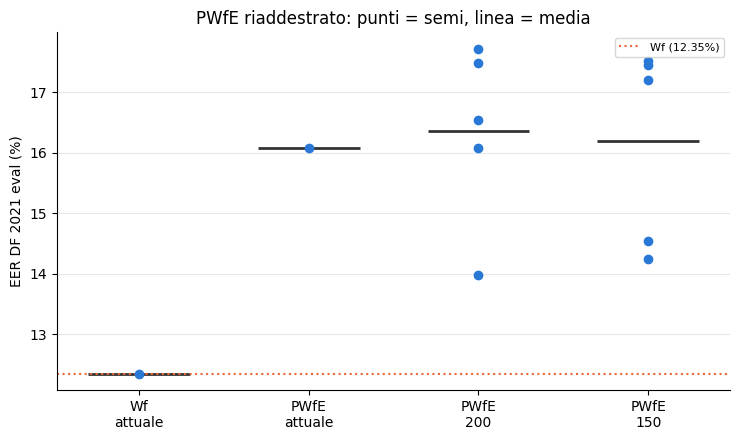

Output: ['contrasti_eval.csv', 'eval_metrics.py', 'fig_pwfe_eval.png', 'per_codec_eval.csv', 'per_source_eval.csv', 'preproc_prosody_PWfE_150.json', 'preproc_prosody_PWfE_200.json', 'riepilogo.json', 'riepilogo_dev.csv', 'riepilogo_eval.csv', 'risultati_dev.csv', 'risultati_eval.csv', 'standardizer.json', 'storia.csv']


In [7]:
def bootstrap_appaiato(y, s_a, s_b, n_boot=N_BOOT, seed=0):
    g = np.random.default_rng(seed)
    ib, is_ = np.where(y == 1)[0], np.where(y == 0)[0]
    d = []
    for _ in range(n_boot):
        ii = np.concatenate([g.choice(ib, len(ib)), g.choice(is_, len(is_))])
        d.append(compute_eer(y[ii], s_a[ii]) - compute_eer(y[ii], s_b[ii]))
    return np.percentile(100 * np.array(d), [2.5, 97.5])

if "inferenza" in FASE:
    SC = {f.stem: np.load(f) for f in sorted(SCO_EVAL.glob("*.npy"))}
    cfg_di = lambda n: n if n.endswith("_attuale") else n.rsplit("_s", 1)[0]
    righe, gruppi = [], []
    for nome, s in SC.items():
        eer, thr = eer_soglia(Y_E, s)
        righe.append({"modello": nome, "config": cfg_di(nome), "eer_%": 100 * eer, "auc": roc_auc_score(Y_E, s),
                      "soglia_eer": thr, **tassi(Y_E, s, thr)})
        for col in ("source", "codec"):
            for gname in sorted(meta[col].unique()):
                m = (meta[col] == gname).to_numpy()
                if min(int(Y_E[m].sum()), int((1 - Y_E[m]).sum())) < MIN_PER_CLASSE:
                    continue
                tg = tassi(Y_E[m], s[m], thr)
                gruppi.append({"config": cfg_di(nome), "colonna": col, "gruppo": gname,
                               "eer_gruppo_%": 100 * compute_eer(Y_E[m], s[m]),
                               "FPR_%_soglia_globale": tg["FPR_%"], "FNR_%_soglia_globale": tg["FNR_%"]})
    RIS = pd.DataFrame(righe); GR = pd.DataFrame(gruppi)
    RIS.to_csv(OUT_DIR / "risultati_eval.csv", index=False)
    ordine = [c for c in ("Wf_attuale", "PWfE_attuale", "PWfE_200", "PWfE_150") if c in set(RIS["config"])]
    riep = RIS.groupby("config").agg(n=("eer_%", "size"), eer_media=("eer_%", "mean"), eer_std=("eer_%", "std"),
                                     eer_min=("eer_%", "min"), eer_max=("eer_%", "max"), auc_media=("auc", "mean"),
                                     FPR_media=("FPR_%", "mean"), FNR_media=("FNR_%", "mean")).loc[ordine]
    riep.to_csv(OUT_DIR / "riepilogo_eval.csv")
    print("=== DF 2021 eval, per modello ==="); display(RIS.set_index("modello").round(3))
    print("=== DF 2021 eval, per configurazione ==="); display(riep.round(3))
    for col in ("source", "codec"):
        t = GR[GR["colonna"] == col].groupby(["gruppo", "config"])[
            ["eer_gruppo_%", "FPR_%_soglia_globale", "FNR_%_soglia_globale"]].mean().unstack("config")
        t = t.reindex(columns=ordine, level=1); t.to_csv(OUT_DIR / f"per_{col}_eval.csv")
        print(f"\n=== per {col} (media sui semi; FPR/FNR alla soglia di EER globale) ==="); display(t.round(2))

    contr = []
    for a, b in (("PWfE_150", "PWfE_200"), ("PWfE_200", "Wf_attuale"), ("PWfE_150", "Wf_attuale")):
        if a not in ordine or b not in ordine:
            continue
        for sd in SEMI:
            nb = b if b.endswith("_attuale") else f"{b}_s{sd}"
            lo, hi = bootstrap_appaiato(Y_E, SC[f"{a}_s{sd}"], SC[nb], seed=sd)
            contr.append({"confronto": f"{a} - {b}", "seme": sd,
                          "delta_%": 100 * (compute_eer(Y_E, SC[f"{a}_s{sd}"]) - compute_eer(Y_E, SC[nb])),
                          "ic_lo": lo, "ic_hi": hi})
    CONTR = pd.DataFrame(contr)
    if len(CONTR):
        CONTR.to_csv(OUT_DIR / "contrasti_eval.csv", index=False)
        print("\n=== confronti appaiati per seme (delta < 0: il primo è migliore) ===")
        display(CONTR.groupby("confronto").agg(delta_medio=("delta_%", "mean"),
                                               semi_migliori=("delta_%", lambda x: int((x < 0).sum())),
                                               semi_ic_sotto_zero=("ic_hi", lambda x: int((x < 0).sum())),
                                               semi_ic_sopra_zero=("ic_lo", lambda x: int((x > 0).sum()))).round(2))

    wf = riep.loc["Wf_attuale", "eer_media"]
    if PREFERITA is None or PREFERITA not in riep.index:
        esito2 = "regola 2 non applicabile: configurazione preferita non definita o non valutata su eval"
    else:
        e_pref = riep.loc[PREFERITA, "eer_media"]
        esito2 = (f"configurazione preferita sul dev: {PREFERITA}, EER eval medio {e_pref:.2f}% contro {wf:.2f}% di Wf -> "
                  + ("SUCCESSO: batte Wf" if e_pref < wf else "NON batte Wf"))
    print("\nREGOLA 2 (eval):", esito2)

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for k, c in enumerate(ordine):
        v = RIS.loc[RIS["config"] == c, "eer_%"].to_numpy()
        ax.scatter(np.full(len(v), k), v, color="#2a78d6", zorder=3)
        ax.hlines(v.mean(), k - 0.3, k + 0.3, color="#333333", lw=2)
    ax.axhline(wf, color="#eb6834", ls=":", lw=1.5, label=f"Wf ({wf:.2f}%)")
    ax.set_xticks(range(len(ordine))); ax.set_xticklabels([c.replace("_", "\n") for c in ordine])
    ax.set_ylabel("EER DF 2021 eval (%)"); ax.set_title("PWfE riaddestrato: punti = semi, linea = media")
    ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=8)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    plt.tight_layout(); plt.savefig(OUT_DIR / "fig_pwfe_eval.png", dpi=150); plt.show()

    (OUT_DIR / "riepilogo.json").write_text(json.dumps({
        "protocollo": "notebook 10 invariato (early stopping, checkpoint e scheduler sull'EER del dev), 5 semi",
        "configurazioni": {"PWfE_200": str(PROS200_TRDEV), "PWfE_150": str(PROS150_TRDEV)},
        "regola_1_dev": "preferita = EER dev medio più basso", "preferita": PREFERITA,
        "eer_dev": riep_dev.round(4).reset_index().to_dict("records"),
        "regola_2_eval": "la preferita deve avere EER eval medio inferiore a Wf", "esito_regola_2": esito2,
        "eer_eval": riep.round(4).reset_index().to_dict("records"),
        "contrasti_eval": CONTR.round(4).to_dict("records") if len(CONTR) else [],
        "limiti": ["Wf è un solo modello (seme 0): il confronto con Wf non include la variabilità di Wf fra semi",
                   "early stopping e scelta sul dev: EER dev ottimista; eval non usato per alcuna scelta",
                   "soglia di EER calcolata a posteriori su eval"],
        "eer_function": {"source": EVAL_METRICS_URL, "sha256": EVAL_METRICS_SHA256}}, indent=2, default=float))
    print("Output:", sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()))